# Notebook 03 — Confidence Interval & Credible Interval
Research Questions yang dijawab:
- RQ1: Berapa probabilitas estimasi sebuah PR akan di-merge?
- RQ2: Apakah rata-rata bug report berubah setelah rilis pandas 2.0?
- RQ3: Berapa probabilitas issue membutuhkan >30 hari untuk ditutup?

**Nama:** Adhinda Zahra Dinanti

**Role:** Inference Analyst

# AI Disclosure

**Member:** Adhinda Zahra Dinanti — Inference Analyst

**Tools used:** Gemini 

| Task                          | Tool                | Prompt summary                                   | Pemanfaatan Output         |
| ----------------------------- | ------------------- | ------------------------------------------------ | ----------------------- |
| Bagaimana rumus bekerja | Gemini      | "buatkan analogi dari rumus rumus yang saya berikan dengan bahasa yang mudah" | Digunakan sebagai brainstorming |
| Pengecekan apakah kode sudah benar | Gemini      | "apakah kode yang saya beri sudah benar?" | Digunakan sebagai validasi kode |

**Written by author:** Seluruh interpretasi hasil, analisis kontekstual, dan kesimpulan
ditulis secara mandiri tanpa bantuan AI atau semacamnya.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import beta as beta_dist
from scipy import stats
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.estimator  import mle_bernoulli, mle_poisson, beta_posterior
from src.inference  import ci_bernoulli, ci_poisson, credible_interval

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")
print("Import berhasil")

Import berhasil


In [8]:
df_pr = pd.read_csv("../data/clean/pulls.csv",  parse_dates=["created_at","closed_at"])
df_iss = pd.read_csv("../data/clean/issues.csv", parse_dates=["created_at","closed_at"])

print(f"Pull Requests : {len(df_pr)} baris")
print(f"Issues        : {len(df_iss)} baris")

Pull Requests : 2500 baris
Issues        : 5650 baris


In [9]:
data_bernoulli = df_pr["is_merged"].values
mle_b = mle_bernoulli(data_bernoulli)
k, n = mle_b["k"], mle_b["n"]

ci_90 = ci_bernoulli(k, n, confidence=0.90)
ci_95 = ci_bernoulli(k, n, confidence=0.95)
ci_99 = ci_bernoulli(k, n, confidence=0.99)

print("  Confidence Interval — PR Merge Rate (Bernoulli)")

for conf, ci_result in [("90%", ci_90), ("95%", ci_95), ("99%", ci_99)]:
    print(f"  CI {conf}: [{ci_result['lower']:.4f}, {ci_result['upper']:.4f}]" f"  ±{ci_result['margin_of_error']:.4f}")

print(f"\n  θ̂ MLE = {mle_b['theta_hat']:.4f}")

  Confidence Interval — PR Merge Rate (Bernoulli)
  CI 90%: [0.6748, 0.7052]  ±0.0152
  CI 95%: [0.6719, 0.7081]  ±0.0181
  CI 99%: [0.6662, 0.7138]  ±0.0238

  θ̂ MLE = 0.6900


In [10]:
m = n - k
result_beta = beta_posterior(k, m)
alpha_b = result_beta["alpha"]
beta_b = result_beta["beta"]

cred_90 = credible_interval(alpha_b, beta_b, confidence=0.90)
cred_95 = credible_interval(alpha_b, beta_b, confidence=0.95)
cred_99 = credible_interval(alpha_b, beta_b, confidence=0.99)

print("Credible Interval — PR Merge Rate (Beta Posterior)")
for conf, cr in [("90%", cred_90), ("95%", cred_95), ("99%", cred_99)]:
    print(f"CrI {conf}: [{cr['lower']:.4f}, {cr['upper']:.4f}]")
print(f"\nBeta posterior : a={alpha_b}, β={beta_b}")
print(f"Mean posterior : {cred_95['mean']:.4f}")
print(f"Mode posterior : {cred_95['mode']:.4f}")

Credible Interval — PR Merge Rate (Beta Posterior)
CrI 90%: [0.6746, 0.7050]
CrI 95%: [0.6716, 0.7078]
CrI 99%: [0.6658, 0.7134]

Beta posterior : a=1726, β=776
Mean posterior : 0.6898
Mode posterior : 0.6900


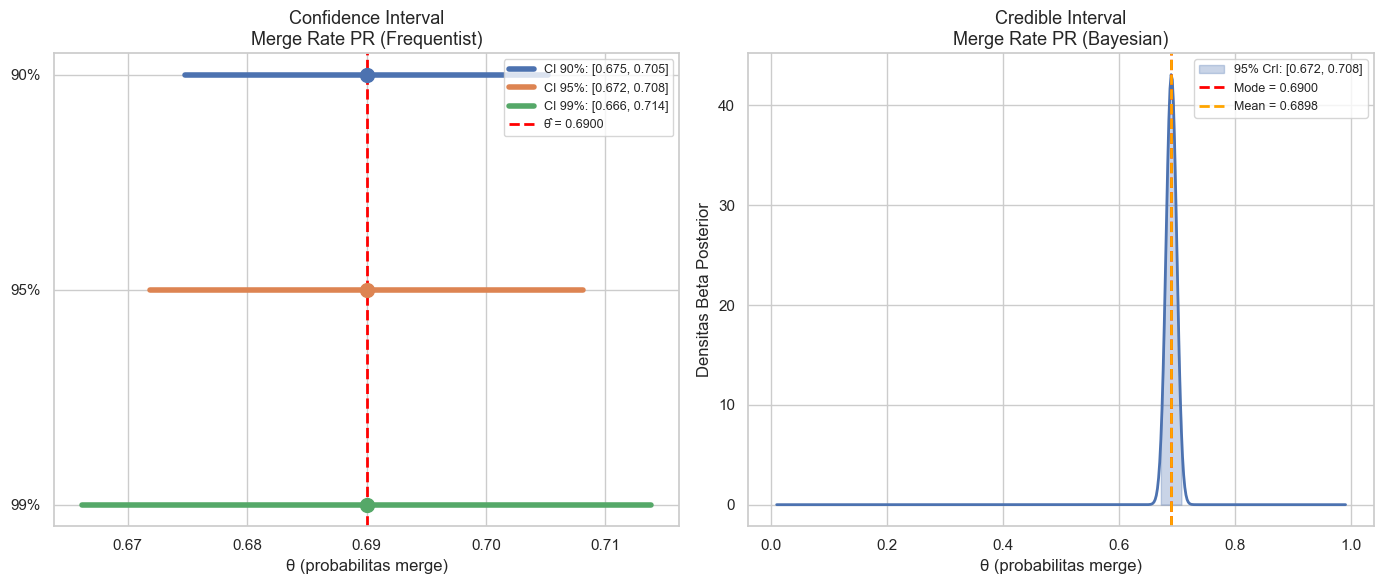

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

levels = ["90%", "95%", "99%"]
ci_lowers = [ci_90["lower"],  ci_95["lower"],  ci_99["lower"]]
ci_uppers = [ci_90["upper"],  ci_95["upper"],  ci_99["upper"]]
y_pos = [3, 2, 1]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, (conf, lo, hi, c) in enumerate(zip(levels, ci_lowers, ci_uppers, colors)):
    axes[0].plot([lo, hi], [y_pos[i], y_pos[i]], color=c, linewidth=4, label=f"CI {conf}: [{lo:.3f}, {hi:.3f}]")
    axes[0].scatter([mle_b["theta_hat"]], [y_pos[i]], color=c, s=100, zorder=5)

axes[0].axvline(mle_b["theta_hat"], color="red", linestyle="--", linewidth=2, label=f"θ̂ = {mle_b['theta_hat']:.4f}")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(levels)
axes[0].set_title("Confidence Interval\nMerge Rate PR (Frequentist)", fontsize=13)
axes[0].set_xlabel("θ (probabilitas merge)")
axes[0].legend(fontsize=9)

theta_range = np.linspace(0.01, 0.99, 500)
pdf_vals = beta_dist.pdf(theta_range, alpha_b, beta_b)

axes[1].plot(theta_range, pdf_vals, color="#4C72B0", linewidth=2)
axes[1].fill_between(theta_range, pdf_vals, where=[(t >= cred_95["lower"] and t <= cred_95["upper"]) for t in theta_range], alpha=0.3, color="#4C72B0", label=f"95% CrI: [{cred_95['lower']:.3f}, {cred_95['upper']:.3f}]")
axes[1].axvline(cred_95["mode"], color="red", linestyle="--", linewidth=2, label=f"Mode = {cred_95['mode']:.4f}")
axes[1].axvline(cred_95["mean"], color="orange", linestyle="--", linewidth=2, label=f"Mean = {cred_95['mean']:.4f}")
axes[1].set_title("Credible Interval\nMerge Rate PR (Bayesian)", fontsize=13)
axes[1].set_xlabel("θ (probabilitas merge)")
axes[1].set_ylabel("Densitas Beta Posterior")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

  Confidence Interval — Bug Report Rate (Poisson)
  λ̂ MLE           : 45.6727 bug/bulan
  CI 95%          : [43.8867, 47.4588]
  CI 99%          : [43.3255, 48.0200]
  Margin of Error : -+ 1.7861


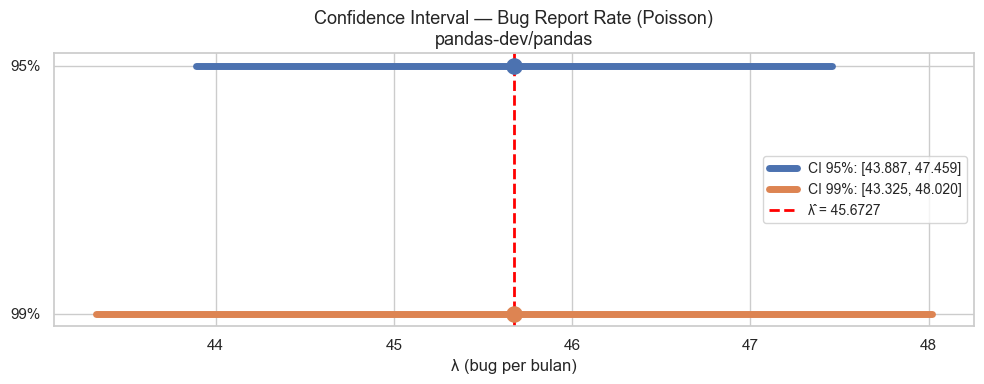

In [ ]:
bug_monthly = df_iss.groupby("year_month")["is_bug"].sum()
bug_data = bug_monthly.values

ci_poisson_95 = ci_poisson(bug_data, confidence=0.95)
ci_poisson_99 = ci_poisson(bug_data, confidence=0.99)

print("  Confidence Interval — Bug Report Rate (Poisson)")
print(f"  λ̂ MLE           : {ci_poisson_95['lambda_hat']:.4f} bug/bulan")
print(f"  CI 95%          : [{ci_poisson_95['lower']:.4f}, {ci_poisson_95['upper']:.4f}]")
print(f"  CI 99%          : [{ci_poisson_99['lower']:.4f}, {ci_poisson_99['upper']:.4f}]")
print(f"  Margin of Error : -+ {ci_poisson_95['margin_of_error']:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
levels = ["95%", "99%"]
ci_list = [ci_poisson_95, ci_poisson_99]
y_pos = [2, 1]
colors = ["#4C72B0", "#DD8452"]

for i, (conf, ci, c) in enumerate(zip(levels, ci_list, colors)):
    ax.plot([ci["lower"], ci["upper"]], [y_pos[i], y_pos[i]], color=c, linewidth=5, label=f"CI {conf}: [{ci['lower']:.3f}, {ci['upper']:.3f}]")
    ax.scatter([ci["lambda_hat"]], [y_pos[i]], color=c, s=120, zorder=5)

ax.axvline(ci_poisson_95["lambda_hat"], color="red", linestyle="--", linewidth=2, label=f"λ̂ = {ci_poisson_95['lambda_hat']:.4f}")
ax.set_yticks(y_pos)
ax.set_yticklabels(levels)
ax.set_title("Confidence Interval — Bug Report Rate (Poisson)\npandas-dev/pandas", fontsize=13)
ax.set_xlabel("λ (bug per bulan)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Summary 

| Variabel | Nilai | Digunakan di |
| :--- | :--- | :--- |
| CI Bernoulli (PR merge rate) | Output sel 3 | Notebook 03, Notebook 04 |
| CrI Beta Posterior (Bayesian merge rate) | Output sel 4 | Notebook 03 |
| CI Poisson | Output sel 6 | Notebook 03, Notebook 04 |
| λ̂ MLE | Output sel 6 | Notebook 03 |

## Output untuk Role Berikutnya

### Member D (Hypothesis Testing):
- `ci_bernoulli` -> pakai ini untuk mengecek tebakan angka $H_0$
- buat `ci_poisson_before` dan `ci_poisson_after` untuk membuat grafik perbandingannya, gunakan ci_poisson yang sudah ada disini.
- buat `bug_before` dan `bug_after` dari  λ̂ MLE yang sudah diketahui

### Member E (Simulation):
- Rentang `credible_interval` -> gunakan batas interval kredibel (Bayesian) ini sebagai acuan validasi hasil simulasi *MCMC* atau *Monte Carlo* untuk skenario *merge*. 